In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [70]:
# transformers and pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.model_selection import learning_curve, validation_curve

# ml models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [71]:
pipe_lr = make_pipeline(StandardScaler(), LogisticRegression(
                                                             max_iter=10000))


In [72]:
df = pd.read_csv('data/breast_cancer_diagnostic/wdbc.data', header=None)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X = df.iloc[:, 2:].values
y = df.iloc[:, 1].values
y = le.fit_transform(y)
le.classes_

array(['B', 'M'], dtype=object)

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [74]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=pipe_lr, X=X_train,y=y_train,
    train_sizes=np.linspace(0.1,1.0,10),
    cv=10, n_jobs=1
)

In [75]:
train_mean = np.mean(train_scores,axis=1)
train_std = np.std(train_scores,axis=1)
test_mean = np.mean(test_scores,axis=1)
test_std = np.std(test_scores,axis=1)

C:\Users\owner\AppData\Local\Temp\ipykernel_14160\3020388460.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


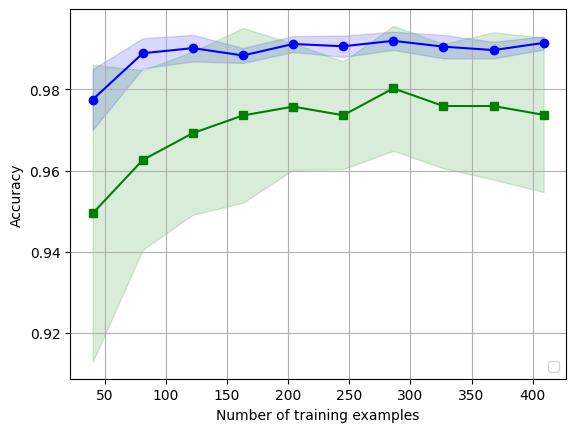

In [76]:
plt.plot(train_sizes,train_mean,color='blue',marker='o')
plt.fill_between(train_sizes,train_mean+train_std,train_mean-train_std,alpha=0.15,color='blue')
plt.plot(train_sizes,test_mean, color='green',marker='s')
plt.fill_between(train_sizes,test_mean+test_std,test_mean-test_std,alpha=0.15,color='green')
plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()


In [77]:
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores, test_scores = validation_curve(
    estimator=pipe_lr, X=X_train, y=y_train,
    param_name='logisticregression__C',
    param_range=param_range,
    cv=10, n_jobs=1
)

In [78]:
train_mean = np.mean(train_scores,axis=1)
train_std = np.std(train_scores,axis=1)
test_mean = np.mean(test_scores,axis=1)
test_std = np.std(test_scores,axis=1)


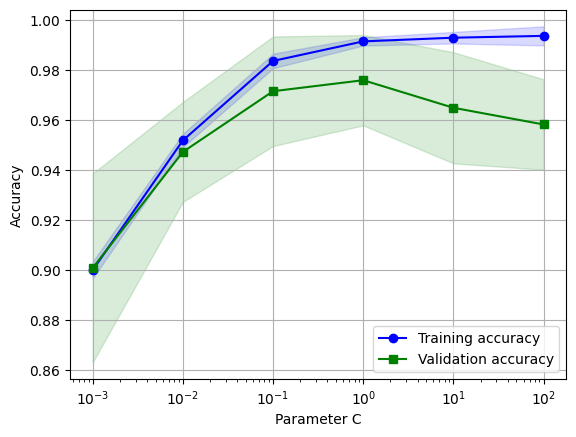

In [79]:
plt.plot(param_range, train_mean, color='blue', marker='o',label='Training accuracy')
plt.fill_between(param_range, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
plt.plot(param_range, test_mean, color='green', marker='s',label='Validation accuracy')
plt.fill_between(param_range, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
plt.xscale('log')
plt.grid()
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()